<div style="background:linear-gradient(135deg,#0A1A2F 0%,#123B55 55%,#15757B 100%);padding:36px 32px;border-radius:14px;color:white;font-family:Arial">
  <div style="font-size:12px;letter-spacing:3px;color:#37C5CB;font-weight:700">LAB 02 &nbsp;·&nbsp; TRY THE MODEL &nbsp;·&nbsp; 13 MIN + OPTIONAL CAMERA</div>
  <div style="font-size:35px;font-weight:800;margin:10px 0 6px;line-height:1.15">Road Vehicle Detector</div>
  <div style="font-size:16px;color:#cfe9ec;max-width:700px;line-height:1.6">
    Load the model you trained, then try it three different ways, each one in its own cell.
  </div>
</div>

<div style="border-left:4px solid #37C5CB;background:#F1FBFC;padding:13px 18px;margin:12px 0;border-radius:0 7px 7px 0;font-family:Arial">
<b style="color:#37C5CB;font-size:14px">Three ways to try the model, run whichever you want</b>
<ul style="margin:8px 0 0;padding-left:20px;color:#1a2b3c;font-size:14px;line-height:1.7">
  <li style="margin:4px 0"><b>03. The app.</b> A small interface with drag and drop. This is the one for the presentation.</li>
  <li style="margin:4px 0"><b>04. Quick upload.</b> No interface at all: pick a file, see the result.</li>
  <li style="margin:4px 0"><b>05. Camera.</b> A separate app. It opens the camera <b>only</b> when you run that cell.</li>
  <li style="margin:4px 0">Cells 01 and 02 are needed first. After that the three are independent.</li>
</ul>
</div>

<div style="display:flex;align-items:center;gap:10px;margin:30px 0 4px">
  <div style="background:#0A1A2F;color:#37C5CB;font-weight:800;font-size:15px;padding:7px 14px;border-radius:7px;font-family:Arial">01</div>
  <div style="flex:1">
    <div style="font-size:23px;font-weight:800;color:#0A1A2F;font-family:Arial;line-height:1.2">Install</div>
    <div style="font-size:14px;color:#5a6b7c;font-family:Arial;margin-top:3px">Once per session</div>
  </div>
  <div style="font-family:Arial;font-size:12px;font-weight:700;color:#7b8b99;border:1px solid #dde5e9;padding:5px 11px;border-radius:20px">2 min</div>
</div>
<div style="height:3px;background:linear-gradient(90deg,#37C5CB,rgba(55,197,203,0));margin:10px 0 16px"></div>

In [1]:
!pip install -q ultralytics gradio==6.21.0

from google.colab import drive
drive.mount("/content/drive")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.7/30.7 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 4.1 MB/s eta 0:00:00
Mounted at /content/drive


<div style="display:flex;align-items:center;gap:10px;margin:30px 0 4px">
  <div style="background:#0A1A2F;color:#37C5CB;font-weight:800;font-size:15px;padding:7px 14px;border-radius:7px;font-family:Arial">02</div>
  <div style="flex:1">
    <div style="font-size:23px;font-weight:800;color:#0A1A2F;font-family:Arial;line-height:1.2">Load the model</div>
    <div style="font-size:14px;color:#5a6b7c;font-family:Arial;margin-top:3px">The one you trained in Lab 01</div>
  </div>
  <div style="font-family:Arial;font-size:12px;font-weight:700;color:#7b8b99;border:1px solid #dde5e9;padding:5px 11px;border-radius:20px">1 min</div>
</div>
<div style="height:3px;background:linear-gradient(90deg,#37C5CB,rgba(55,197,203,0));margin:10px 0 16px"></div>

In [2]:
import os, glob, cv2
from ultralytics import YOLO
from PIL import Image

PROJECT_DIR = "/content/drive/MyDrive/YOLO_Vehicle_Lab"
WEIGHTS     = PROJECT_DIR + "/models/vehicle_best.pt"

if not os.path.exists(WEIGHTS):   # fall back to the newest training run
    found = sorted(glob.glob(PROJECT_DIR + "/**/weights/best.pt", recursive=True), key=os.path.getmtime)
    WEIGHTS = found[-1] if found else "yolov8n.pt"

model    = YOLO(WEIGHTS)
CLASSES  = [model.names[i] for i in sorted(model.names)]
EXAMPLES = sorted(glob.glob(PROJECT_DIR + "/**/valid/images/*.jpg", recursive=True))[:3]

def draw(r):
    """Result -> annotated PIL image."""
    return Image.fromarray(cv2.cvtColor(r.plot(line_width=3), cv2.COLOR_BGR2RGB))

print("Model  :", WEIGHTS)
print("Classes:", CLASSES)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Model  : /content/drive/MyDrive/YOLO_Vehicle_Lab/models/vehicle_best.pt
Classes: ['Ambulance', 'Bus', 'Car', 'Motorcycle', 'Truck']


<div style="display:flex;align-items:center;gap:10px;margin:30px 0 4px">
  <div style="background:#0A1A2F;color:#37C5CB;font-weight:800;font-size:15px;padding:7px 14px;border-radius:7px;font-family:Arial">03</div>
  <div style="flex:1">
    <div style="font-size:23px;font-weight:800;color:#0A1A2F;font-family:Arial;line-height:1.2">The app</div>
    <div style="font-size:14px;color:#5a6b7c;font-family:Arial;margin-top:3px">Drag a photo in, move the slider, press Detect</div>
  </div>
  <div style="font-family:Arial;font-size:12px;font-weight:700;color:#7b8b99;border:1px solid #dde5e9;padding:5px 11px;border-radius:20px">8 min</div>
</div>
<div style="height:3px;background:linear-gradient(90deg,#37C5CB,rgba(55,197,203,0));margin:10px 0 16px"></div>

<div style="border-left:4px solid #37C5CB;background:#F1FBFC;padding:13px 18px;margin:12px 0;border-radius:0 7px 7px 0;font-family:Arial">
<b style="color:#37C5CB;font-size:14px">What the trainee sees</b>
<ul style="margin:8px 0 0;padding-left:20px;color:#1a2b3c;font-size:14px;line-height:1.7">
  <li style="margin:4px 0">Left: the photo box and the confidence slider. Right: the photo with boxes, and what was found.</li>
  <li style="margin:4px 0"><b>Confidence</b> is the minimum score for a box to be shown. Raise it to remove weak guesses, lower it to catch more.</li>
  <li style="margin:4px 0">The photo box accepts <b>upload and paste only</b>. No camera, so nothing opens during the presentation.</li>
  <li style="margin:4px 0">The cell prints a public link. Open it on a phone to try it there too.</li>
</ul>
</div>

In [3]:
import gradio as gr

def detect(image, confidence):
    if image is None:
        return None, {}
    r = model.predict(image, conf=confidence, verbose=False)[0]
    scores = {}
    for b in r.boxes:                       # highest score per class
        name = CLASSES[int(b.cls)]
        scores[name] = max(scores.get(name, 0.0), float(b.conf))
    return draw(r), scores

with gr.Blocks(title="Road Vehicle Detector") as app:
    gr.Markdown("## Road Vehicle Detector\nUpload a road photo. The model marks every vehicle it finds.")
    with gr.Row():
        with gr.Column():
            inp  = gr.Image(type="pil", sources=["upload", "clipboard"], label="Your photo")
            conf = gr.Slider(minimum=0.05, maximum=0.95, value=0.35, step=0.05,
                             label="Confidence", info="Higher = fewer but surer detections")
            btn  = gr.Button("Detect", variant="primary")
        with gr.Column():
            out_img = gr.Image(type="pil", label="Detections")
            out_lbl = gr.Label(label="Found")
    btn.click(detect, inputs=[inp, conf], outputs=[out_img, out_lbl])
    if EXAMPLES:
        gr.Examples(examples=EXAMPLES, inputs=inp, label="Try one of these")

app.launch(share=True, theme=gr.themes.Soft(primary_hue="teal"))

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://460ade31430dc19450.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


<div style="border-left:4px solid #37C5CB;background:#F1FBFC;padding:13px 18px;margin:12px 0;border-radius:0 7px 7px 0;font-family:Arial">
<b style="color:#37C5CB;font-size:14px">Try this</b>
<ul style="margin:8px 0 0;padding-left:20px;color:#1a2b3c;font-size:14px;line-height:1.7">
  <li style="margin:4px 0">Slide the confidence from 0.9 down to 0.1 on the same photo, and detections appear one by one. The model did not change, only the threshold did.</li>
  <li style="margin:4px 0">Try a night photo or one taken from above, and the confidence drops, and that tells you which photos the dataset is missing.</li>
</ul>
</div>

<div style="display:flex;align-items:center;gap:10px;margin:30px 0 4px">
  <div style="background:#0A1A2F;color:#37C5CB;font-weight:800;font-size:15px;padding:7px 14px;border-radius:7px;font-family:Arial">04</div>
  <div style="flex:1">
    <div style="font-size:23px;font-weight:800;color:#0A1A2F;font-family:Arial;line-height:1.2">Quick upload</div>
    <div style="font-size:14px;color:#5a6b7c;font-family:Arial;margin-top:3px">No interface, just pick a file and see the result</div>
  </div>
  <div style="font-family:Arial;font-size:12px;font-weight:700;color:#7b8b99;border:1px solid #dde5e9;padding:5px 11px;border-radius:20px">2 min</div>
</div>
<div style="height:3px;background:linear-gradient(90deg,#37C5CB,rgba(55,197,203,0));margin:10px 0 16px"></div>

Saving download (1).webp to download (1).webp

image 1/1 /content/download (1).webp: 416x640 6 Cars, 235.0ms
Speed: 7.6ms preprocess, 235.0ms inference, 1.4ms postprocess per image at shape (1, 3, 416, 640)


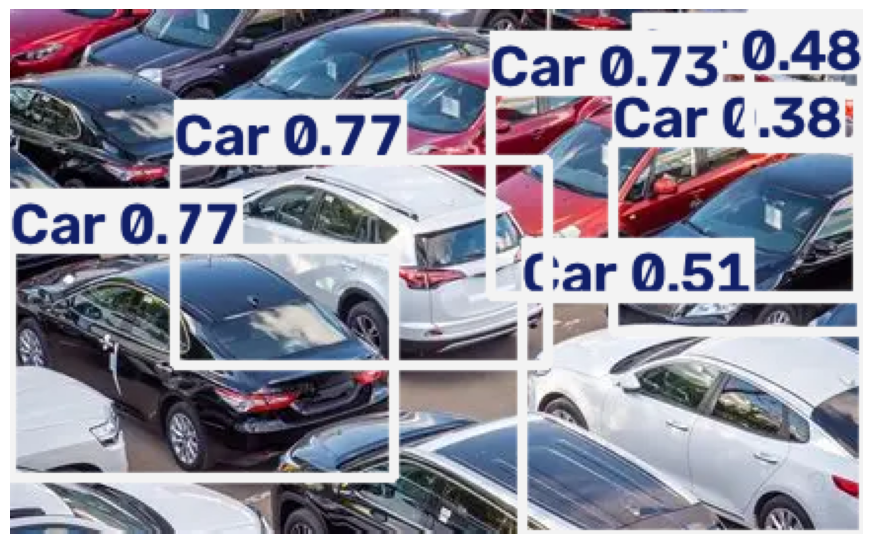

Detected: {'Car': 6}


In [4]:
from google.colab import files
from collections import Counter
import matplotlib.pyplot as plt

uploaded = files.upload()
r = model(next(iter(uploaded)), conf=0.35)[0]

plt.figure(figsize=(11, 8))
plt.imshow(draw(r)); plt.axis("off"); plt.show()
print("Detected:", dict(Counter(CLASSES[int(b.cls)] for b in r.boxes)) or "nothing found")

<div style="display:flex;align-items:center;gap:10px;margin:30px 0 4px">
  <div style="background:#0A1A2F;color:#37C5CB;font-weight:800;font-size:15px;padding:7px 14px;border-radius:7px;font-family:Arial">05</div>
  <div style="flex:1">
    <div style="font-size:23px;font-weight:800;color:#0A1A2F;font-family:Arial;line-height:1.2">Camera</div>
    <div style="font-size:14px;color:#5a6b7c;font-family:Arial;margin-top:3px">A separate app that opens the camera only when you run it</div>
  </div>
  <div style="font-family:Arial;font-size:12px;font-weight:700;color:#e0a030;border:1px solid #e0a030;padding:5px 11px;border-radius:20px">OPTIONAL</div><div style="font-family:Arial;font-size:12px;font-weight:700;color:#7b8b99;border:1px solid #dde5e9;padding:5px 11px;border-radius:20px">3 min</div>
</div>
<div style="height:3px;background:linear-gradient(90deg,#37C5CB,rgba(55,197,203,0));margin:10px 0 16px"></div>

<div style="border-left:4px solid #e0a030;background:#FDF7EA;padding:13px 18px;margin:12px 0;border-radius:0 7px 7px 0;font-family:Arial">
<b style="color:#e0a030;font-size:14px">Run this cell only when you want the camera</b>
<ul style="margin:8px 0 0;padding-left:20px;color:#1a2b3c;font-size:14px;line-height:1.7">
  <li style="margin:4px 0">It is a separate app. Nothing above it touches the camera.</li>
  <li style="margin:4px 0">The browser asks for permission the first time. Works in Chrome.</li>
  <li style="margin:4px 0">To close it, press the stop button on the cell.</li>
</ul>
</div>

In [5]:
import gradio as gr

def detect_frame(frame, confidence):
    if frame is None:
        return None
    return draw(model.predict(frame, conf=confidence, verbose=False)[0])

with gr.Blocks(title="Live Camera") as camera_app:
    gr.Markdown("## Live camera\nPoint the camera at the street, or at a phone showing a traffic photo.")
    conf_cam = gr.Slider(minimum=0.05, maximum=0.95, value=0.35, step=0.05, label="Confidence")
    with gr.Row():
        cam  = gr.Image(sources=["webcam"], streaming=True, type="pil", label="Camera")
        live = gr.Image(type="pil", label="Live detections")
    cam.stream(detect_frame, inputs=[cam, conf_cam], outputs=live, stream_every=0.5)

camera_app.launch(share=True, theme=gr.themes.Soft(primary_hue="teal"))

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ab6dda4434ec5a7bd5.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


<div style="background:linear-gradient(135deg,#0A1A2F,#15757B);padding:24px 28px;border-radius:12px;color:white;font-family:Arial;margin-top:26px">
  <div style="font-size:22px;font-weight:800;margin-bottom:6px">That is the whole pipeline</div>
  <div style="font-size:15px;color:#cfe9ec;line-height:1.6">
    Lab 01 built the model. Lab 02 turned it into something anyone can use with a photo.
  </div>
</div>